# Dataset Loading & Exploratory Data Analysis


In [222]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
import os

# Download the Dataset (Kaggle)

In [223]:
# Download the latest version of the dataset
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

# Print the download path
print("Dataset Path:", path)

Dataset Path: C:\Users\Santosh verma\.cache\kagglehub\datasets\vjchoudhary7\customer-segmentation-tutorial-in-python\versions\1


## Find the CSV File

In [224]:
# List all files in the downloaded folder
os.listdir(path)

['Mall_Customers.csv']

In [225]:
# Create the full file path
file_path = os.path.join(path, "Mall_Customers.csv")

# Load the dataset
df = pd.read_csv(file_path)

In [226]:
# Show first 10 rows

df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [227]:
print("Shape :", df.shape)

Shape : (200, 5)


In [228]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


## Rename Columns for clarity

In [229]:
# Rename columns

df.rename(columns={
    "Genre":"Gender",
    "Annual Income (k$)":"AnnualIncome",
    "Spending Score (1-100)":"SpendingScore"
}, inplace=True)

## Check Column Names

In [230]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore'], dtype='str')


## Check Missing Values

In [231]:
print(df.isnull().sum())

CustomerID       0
Gender           0
Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64


## Male vs Female Customers

In [232]:
# Gender count
print(df["Gender"].value_counts())

Gender
Female    112
Male       88
Name: count, dtype: int64


## Percentage of Male and Female

In [ ]:
print(df["Gender"].value_counts(normalize=True)*100)

Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64


# 1.2 Univariate Analysis

## Histogram of Age

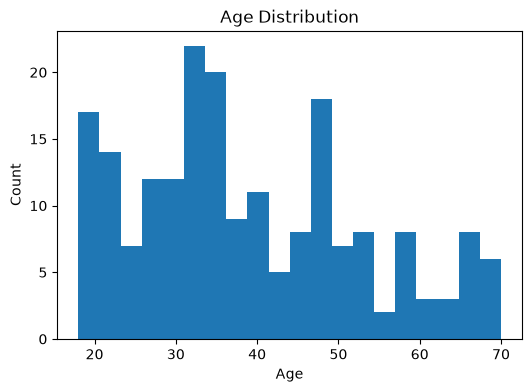

In [234]:
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## Histogram of Annual Income

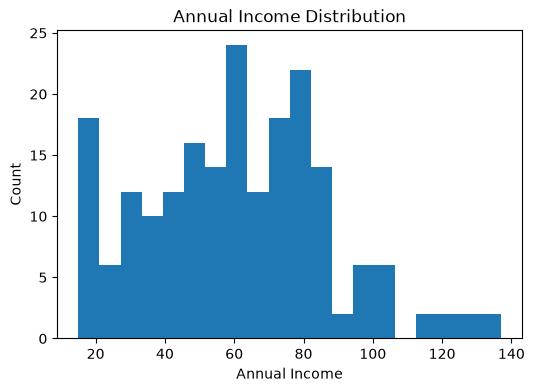

In [235]:
plt.figure(figsize=(6,4))
plt.hist(df["AnnualIncome"], bins=20)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Count")
plt.show()

## Histogram of Spending Score

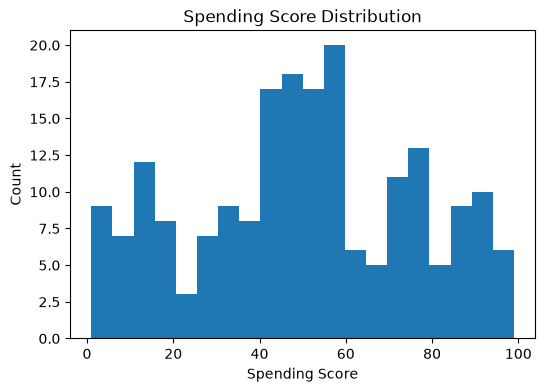

In [236]:
plt.figure(figsize=(6,4))
plt.hist(df["SpendingScore"], bins=20)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")
plt.show()

## Boxplot of Age

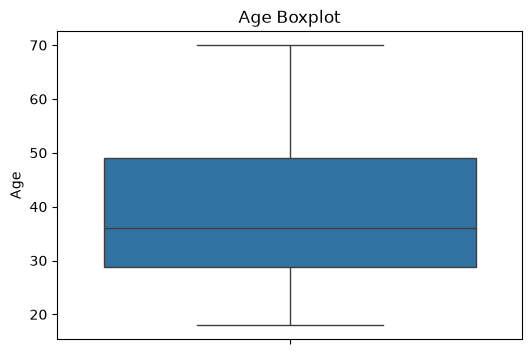

In [237]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Age"])
plt.title("Age Boxplot")
plt.show()

## Boxplot of Annual Income

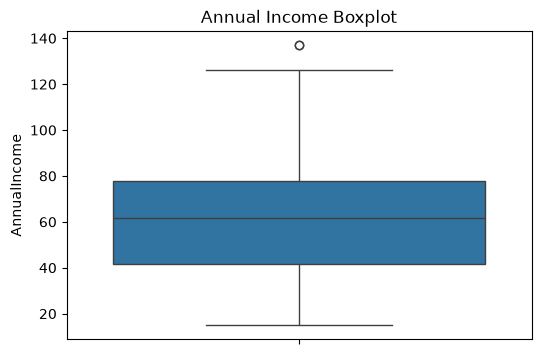

In [238]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["AnnualIncome"])
plt.title("Annual Income Boxplot")
plt.show()

## Boxplot of Spending Score

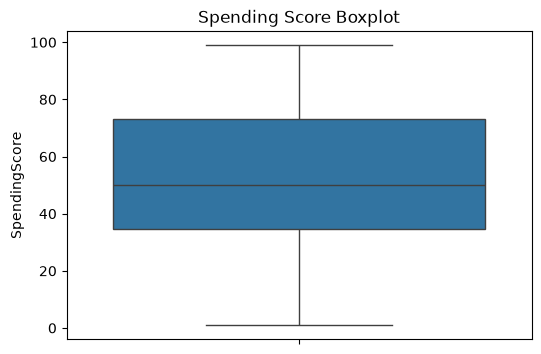

In [239]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["SpendingScore"])
plt.title("Spending Score Boxplot")
plt.show()

## Countplot of Gender

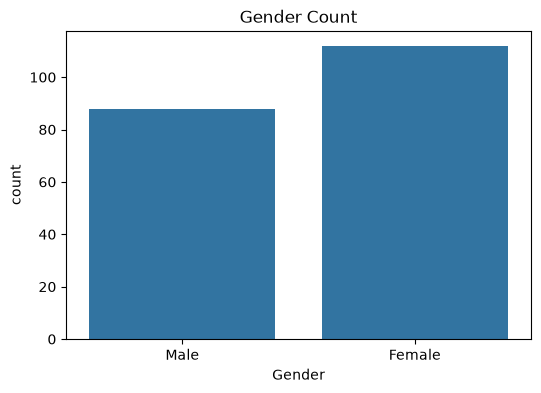

In [240]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Count")
plt.show()

# 1.3 Bivariate Analysis

## Annual Income vs Spending Score

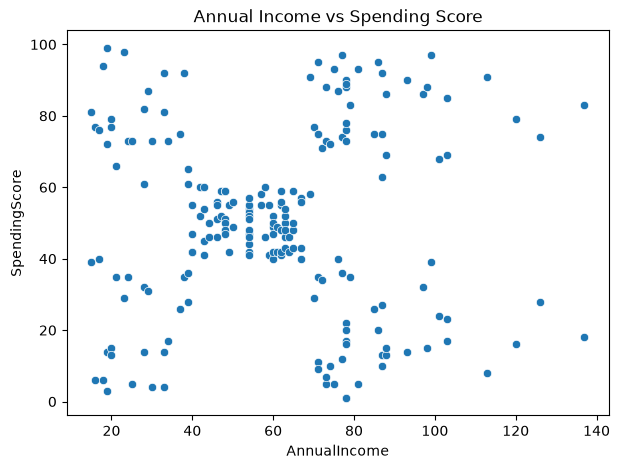

In [241]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="AnnualIncome",
                y="SpendingScore",
                data=df)
plt.title("Annual Income vs Spending Score")
plt.show()

## Age vs Spending Score (Colored by Gender)

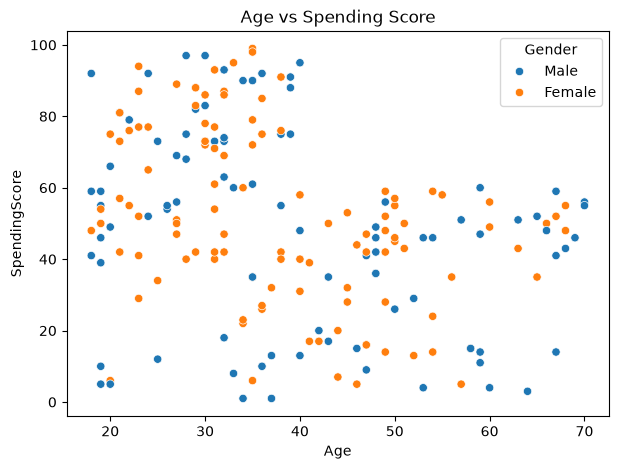

In [242]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Age",
                y="SpendingScore",
                hue="Gender",
                data=df)
plt.title("Age vs Spending Score")
plt.show()

## Age vs Annual Income (Colored by Gender)

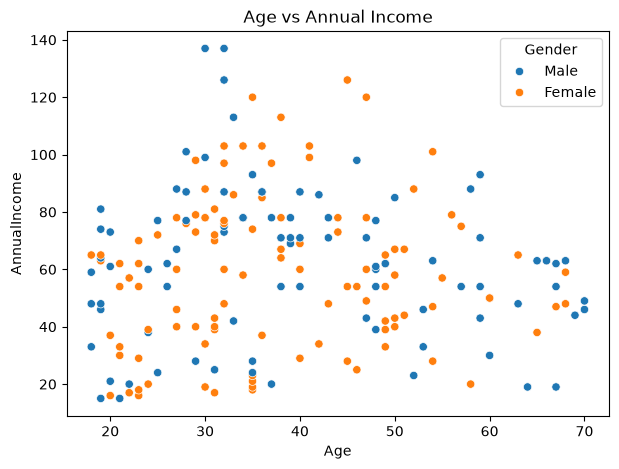

In [243]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Age",
                y="AnnualIncome",
                hue="Gender",
                data=df)
plt.title("Age vs Annual Income")
plt.show()

## Correlation Matrix

In [244]:
corr = df.select_dtypes(include="number").corr()

print(corr)

               CustomerID       Age  AnnualIncome  SpendingScore
CustomerID       1.000000 -0.026763      0.977548       0.013835
Age             -0.026763  1.000000     -0.012398      -0.327227
AnnualIncome     0.977548 -0.012398      1.000000       0.009903
SpendingScore    0.013835 -0.327227      0.009903       1.000000


## Heatmap

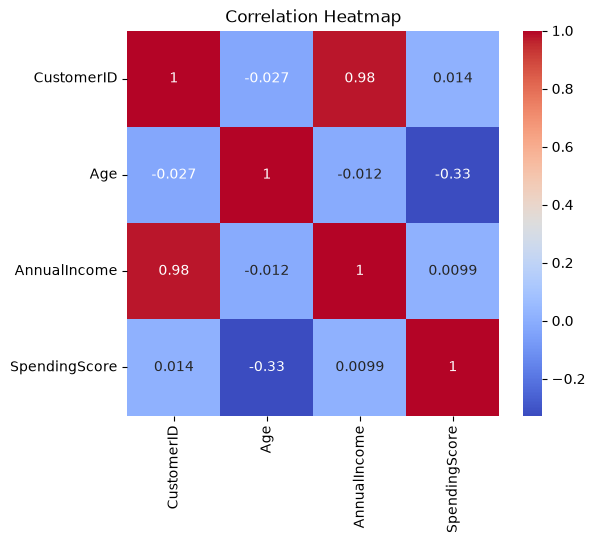

In [245]:
plt.figure(figsize=(6,5))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 1.4 Gender-wise Summary

## Mean Values

In [246]:
summary = df.groupby("Gender")[["Age","AnnualIncome","SpendingScore"]].mean()

print(summary)

              Age  AnnualIncome  SpendingScore
Gender                                        
Female  38.098214     59.250000      51.526786
Male    39.806818     62.227273      48.511364


## Bar Chart

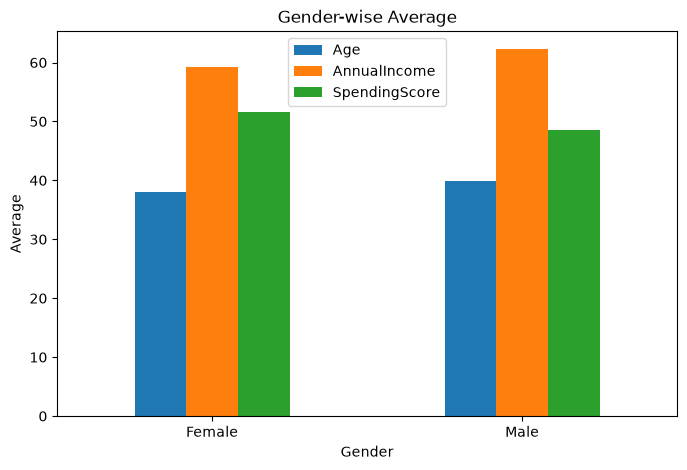

In [247]:
summary.plot(kind="bar", figsize=(8,5))
plt.title("Gender-wise Average")
plt.ylabel("Average")
plt.xticks(rotation=0)
plt.show()

# Observations 
* The dataset contains 200 customers and 5 columns.
* There are no missing values.
* The numbers of male and female customers are nearly balanced.
* Annual Income vs Spending Score shows visible customer groups, suggesting clustering is suitable.
* Age has a few outliers, while Annual Income and Spending Score have no major outliers.
* Correlation between numerical features is generally weak, indicating each feature contributes different information for clustering.

# 2: Feature Engineering & Preprocessing

In [248]:
# Import library

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

## 2.1 Encode Categorical Feature

In [249]:
# Create LabelEncoder object
le = LabelEncoder()

# Encode Gender column
df["Gender_enc"] = le.fit_transform(df["Gender"])

# Display first 10 rows
df[["Gender","Gender_enc"]].head(10)

,Gender,Gender_enc
0,Male,1
1,Male,1
2,Female,0
3,Female,0
4,Female,0
5,Female,0
6,Female,0
7,Female,0
8,Male,1
9,Female,0


## Check Encoded Values

In [250]:
print(df["Gender_enc"].value_counts())

Gender_enc
0    112
1     88
Name: count, dtype: int64


## 2.2 Engineer New Features

In [251]:
# Create IncomeGroup

df["IncomeGroup"] = pd.qcut(
    df["AnnualIncome"],
    q=3,
    labels=["Low","Medium","High"]
)

# Display first rows

df[["AnnualIncome","IncomeGroup"]].head()

,AnnualIncome,IncomeGroup
0,15,Low
1,15,Low
2,16,Low
3,16,Low
4,17,Low


## Check Income Group Count

In [252]:
print(df["IncomeGroup"].value_counts())

IncomeGroup
Low       70
High      66
Medium    64
Name: count, dtype: int64


## Create Age Group

In [253]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[17,25,40,55,100],
    labels=["Young","Adult","Middle-Aged","Senior"]
)

# Display

df[["Age","AgeGroup"]].head()

,Age,AgeGroup
0,19,Young
1,21,Young
2,20,Young
3,23,Young
4,31,Adult


In [254]:
print(df["AgeGroup"].value_counts())

AgeGroup
Adult          84
Middle-Aged    49
Young          38
Senior         29
Name: count, dtype: int64


## Create Spending Category

In [255]:
df["SpendingCategory"] = pd.cut(
    df["SpendingScore"],
    bins=[0,33,66,100],
    labels=["Low","Medium","High"]
)

# Display

df[["SpendingScore","SpendingCategory"]].head()

,SpendingScore,SpendingCategory
0,39,Medium
1,81,High
2,6,Low
3,77,High
4,40,Medium


In [256]:
print(df["SpendingCategory"].value_counts())

SpendingCategory
Medium    94
High      57
Low       49
Name: count, dtype: int64


## Display New Dataset

In [257]:
df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,Gender_enc,IncomeGroup,AgeGroup,SpendingCategory
0,1,Male,19,15,39,1,Low,Young,Medium
1,2,Male,21,15,81,1,Low,Young,High
2,3,Female,20,16,6,0,Low,Young,Low
3,4,Female,23,16,77,0,Low,Young,High
4,5,Female,31,17,40,0,Low,Adult,Medium


## 2.3 Select Features for Clustering

## Experiment A (2D Features)

In [258]:
# Select two features

X_2d = df[["AnnualIncome","SpendingScore"]]

# Display
X_2d.head()

,AnnualIncome,SpendingScore
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Experiment B (4D Features)

In [259]:
# Select four features
X_5d = df[["Age",
           "AnnualIncome",
           "SpendingScore",
           "Gender_enc"]]

# Display

X_5d.head()

,Age,AnnualIncome,SpendingScore,Gender_enc
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


## Check Shapes

In [260]:
print("X_2d Shape :", X_2d.shape)
print("X_5d Shape :", X_5d.shape)

X_2d Shape : (200, 2)
X_5d Shape : (200, 4)


## 2.4 Scale the Features

In [261]:
# Create scaler

scaler = StandardScaler()

## Scale 2D Features

In [262]:
X_2d_scaled = scaler.fit_transform(X_2d)

# Convert to DataFrame

X_2d_scaled = pd.DataFrame(
    X_2d_scaled,
    columns=X_2d.columns
)

X_2d_scaled.head()

,AnnualIncome,SpendingScore
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


## Scale 4D Features

In [263]:
scaler2 = StandardScaler()

X_5d_scaled = scaler2.fit_transform(X_5d)

# Convert to DataFrame

X_5d_scaled = pd.DataFrame(
    X_5d_scaled,
    columns=X_5d.columns
)

X_5d_scaled.head()

,Age,AnnualIncome,SpendingScore,Gender_enc
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


## Check Mean

In [264]:
print("Mean of X_2d_scaled")
print(X_2d_scaled.mean())

print()

print("Mean of X_5d_scaled")
print(X_5d_scaled.mean())

Mean of X_2d_scaled
AnnualIncome    -2.131628e-16
SpendingScore   -1.465494e-16
dtype: float64

Mean of X_5d_scaled
Age             -1.021405e-16
AnnualIncome    -2.131628e-16
SpendingScore   -1.465494e-16
Gender_enc       3.108624e-17
dtype: float64


## Check Standard Deviation

In [265]:
print("Standard Deviation of X_2d_scaled")
print(X_2d_scaled.std())

print()

print("Standard Deviation of X_5d_scaled")
print(X_5d_scaled.std())

Standard Deviation of X_2d_scaled
AnnualIncome     1.002509
SpendingScore    1.002509
dtype: float64

Standard Deviation of X_5d_scaled
Age              1.002509
AnnualIncome     1.002509
SpendingScore    1.002509
Gender_enc       1.002509
dtype: float64


## Final Dataset Information

In [266]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   CustomerID        200 non-null    int64   
 1   Gender            200 non-null    str     
 2   Age               200 non-null    int64   
 3   AnnualIncome      200 non-null    int64   
 4   SpendingScore     200 non-null    int64   
 5   Gender_enc        200 non-null    int64   
 6   IncomeGroup       200 non-null    category
 7   AgeGroup          200 non-null    category
 8   SpendingCategory  200 non-null    category
dtypes: category(3), int64(5), str(1)
memory usage: 10.5 KB
None


# Observations 
* Gender was successfully converted into a numerical feature using Label Encoding.
* Three new features (IncomeGroup, AgeGroup, and SpendingCategory) were created for better customer profiling.
* Two feature sets were prepared:
    * X_2d: AnnualIncome and SpendingScore
    * X_5d (4 features): Age, AnnualIncome, SpendingScore, Gender_enc
* StandardScaler was applied to both feature sets.
The scaled features have a mean close to 0 and a standard deviation close to 1, making them suitable for distance-based clustering algorithms such as K-Means, Agglomerative Clustering, and DBSCAN.

# 3: K-Means Clustering

In [267]:
# Import libraries

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 3.1 Elbow Method (Find Optimal K on X_2d_scaled)

## Calculate Inertia and Silhouette Score

In [268]:
# Empty lists

k_values = []
inertia = []
silhouette = []

# Run KMeans for k = 2 to 10

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )

    model.fit(X_2d_scaled)

    k_values.append(k)
    inertia.append(model.inertia_)

    score = silhouette_score(X_2d_scaled, model.labels_)
    silhouette.append(score)

## Elbow Curve

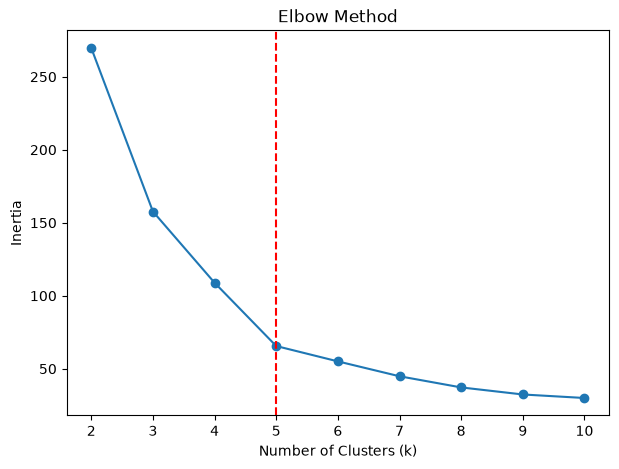

In [269]:
plt.figure(figsize=(7,5))

plt.plot(k_values, inertia, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

# Change 5 if your elbow occurs at another value
plt.axvline(x=5, color="red", linestyle="--")

plt.show()

## Silhouette Score Plot

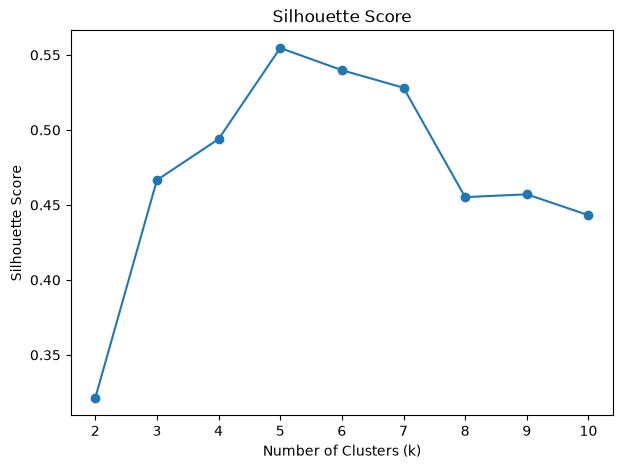

In [270]:
plt.figure(figsize=(7,5))

plt.plot(k_values, silhouette, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Score")

plt.show()

In [271]:
result = pd.DataFrame({
    "K":k_values,
    "Inertia":inertia,
    "Silhouette Score":silhouette
})

print(result)

    K     Inertia  Silhouette Score
0   2  269.691012          0.321271
1   3  157.704008          0.466585
2   4  108.921317          0.493907
3   5   65.568408          0.554657
4   6   55.057348          0.539880
5   7   44.864756          0.528149
6   8   37.228188          0.455215
7   9   32.392268          0.457085
8  10   29.981898          0.443171


# 3.2 Train Final K-Means Model

## 2D Clustering

In [272]:
# Choose optimal k
k_optimal = 5

kmeans = KMeans(
    n_clusters=k_optimal,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42
)

kmeans.fit(X_2d_scaled)

# Add cluster labels

df["KMeans_Cluster"] = kmeans.labels_
print(df.head())

   CustomerID  Gender  Age  AnnualIncome  SpendingScore  Gender_enc  \
0           1    Male   19            15             39           1   
1           2    Male   21            15             81           1   
2           3  Female   20            16              6           0   
3           4  Female   23            16             77           0   
4           5  Female   31            17             40           0   

  IncomeGroup AgeGroup SpendingCategory  KMeans_Cluster  
0         Low    Young           Medium               4  
1         Low    Young             High               2  
2         Low    Young              Low               4  
3         Low    Young             High               2  
4         Low    Adult           Medium               4  


In [273]:
print(kmeans.cluster_centers_)

[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


## Silhouette Score

In [274]:
score_2d = silhouette_score(
    X_2d_scaled,
    df["KMeans_Cluster"]
)

print("Silhouette Score (2D):", score_2d)

Silhouette Score (2D): 0.5546571631111091


## 4D Clustering (Practical labels it as 5D)

In [275]:
kmeans_5d = KMeans(
    n_clusters=k_optimal,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42
)

kmeans_5d.fit(X_5d_scaled)

df["KMeans_5D_Cluster"] = kmeans_5d.labels_

## Silhouette Score (4D)

In [276]:
score_5d = silhouette_score(
    X_5d_scaled,
    df["KMeans_5D_Cluster"]
)

print("Silhouette Score (4D):", score_5d)

Silhouette Score (4D): 0.31437614343154285


## Compare Scores

In [277]:
print("2D Score :", score_2d)
print("4D Score :", score_5d)

2D Score : 0.5546571631111091
4D Score : 0.31437614343154285


# 3.3 Visualize K-Means Clusters

## Annual Income vs Spending Score

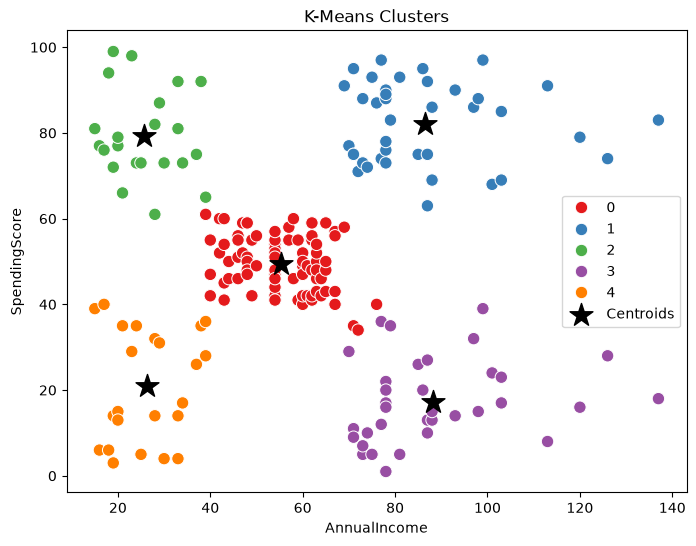

In [278]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="AnnualIncome",
    y="SpendingScore",
    hue="KMeans_Cluster",
    palette="Set1",
    s=80
)
# Plot cluster centers

centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:,0],
    centers[:,1],
    color="black",
    marker="*",
    s=300,
    label="Centroids"
)

plt.title("K-Means Clusters")
plt.legend()
plt.show()

## Age vs Spending Score

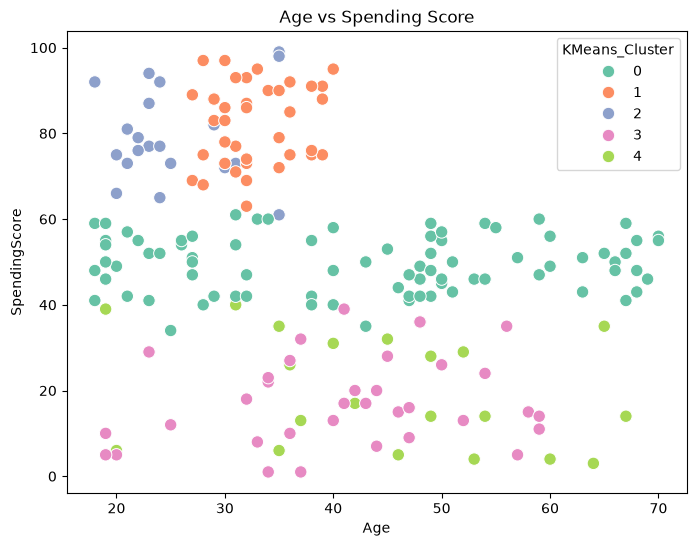

In [279]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="SpendingScore",
    hue="KMeans_Cluster",
    palette="Set2",
    s=80
)

plt.title("Age vs Spending Score")
plt.show()

## PCA for 4D Features

In [280]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_5d_scaled)
pca_df = pd.DataFrame(pca_data, columns=["PC1","PC2"])
pca_df["Cluster"] = df["KMeans_5D_Cluster"]

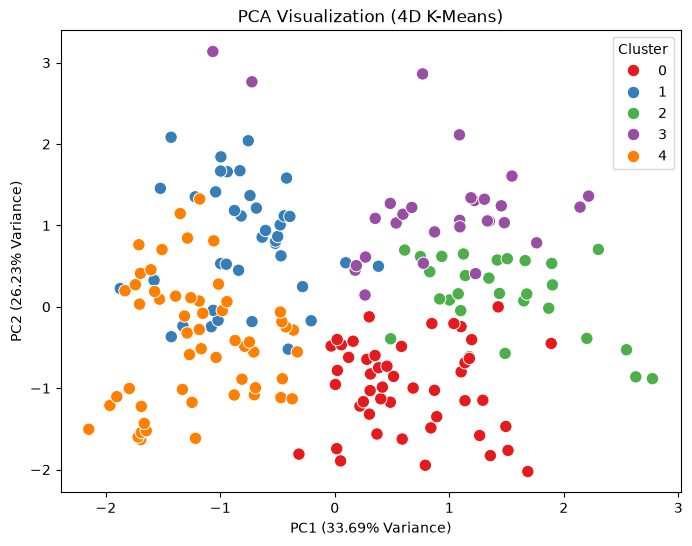

In [281]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("PCA Visualization (4D K-Means)")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)")

plt.show()

# 3.4 Profile K-Means Clusters

## Mean Values

In [282]:
cluster_profile = df.groupby("KMeans_Cluster")[["Age","AnnualIncome","SpendingScore"]].mean()
print(cluster_profile)

                      Age  AnnualIncome  SpendingScore
KMeans_Cluster                                        
0               42.716049     55.296296      49.518519
1               32.692308     86.538462      82.128205
2               25.272727     25.727273      79.363636
3               41.114286     88.200000      17.114286
4               45.217391     26.304348      20.913043


## Gender Distribution

In [283]:
gender_profile = pd.crosstab(
    df["KMeans_Cluster"],
    df["Gender"]
)

print(gender_profile)

Gender          Female  Male
KMeans_Cluster              
0                   48    33
1                   21    18
2                   13     9
3                   16    19
4                   14     9


In [284]:
print(df["KMeans_Cluster"].value_counts())

KMeans_Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


## Assign Customer Personas

In [285]:
persona = {
    0:"Big Spenders",
    1:"Budget Shoppers",
    2:"Careful Spenders",
    3:"Young Aspirers",
    4:"Mature Savers"
}

df["Persona"] = df["KMeans_Cluster"].map(persona)
print(df[["CustomerID","KMeans_Cluster","Persona"]].head(10))

   CustomerID  KMeans_Cluster           Persona
0           1               4     Mature Savers
1           2               2  Careful Spenders
2           3               4     Mature Savers
3           4               2  Careful Spenders
4           5               4     Mature Savers
5           6               2  Careful Spenders
6           7               4     Mature Savers
7           8               2  Careful Spenders
8           9               4     Mature Savers
9          10               2  Careful Spenders


# Observation
* The cluster numbers (0–4) are assigned arbitrarily by K-Means.
* After viewing the cluster_profile table, adjust the persona dictionary so each cluster label matches its actual characteristics (for example, the high-income/high-spending cluster should be labeled "Big Spenders"). This ensures your personas are accurate for your specific model output.

# 4: Agglomerative Hierarchical Clustering

In [286]:
# Import libraries

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score

# 4.1 Dendrogram Analysis (on X_2d_scaled)

In [287]:
# Create linkage matrix

linkage_matrix = linkage(X_2d_scaled, method="ward")

## Plot Full Dendrogram

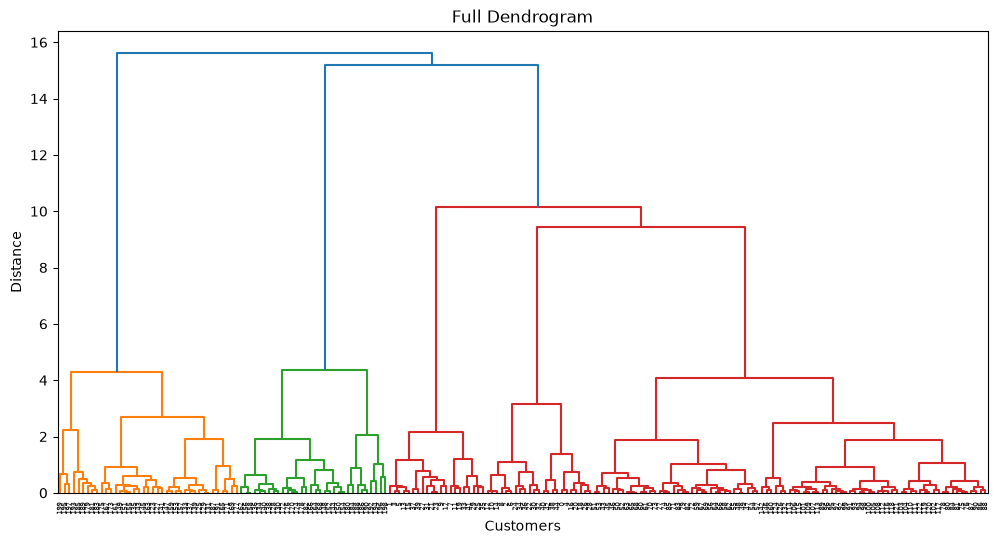

In [288]:
plt.figure(figsize=(12,6))

dendrogram(linkage_matrix)

plt.title("Full Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

## Truncated Dendrogram

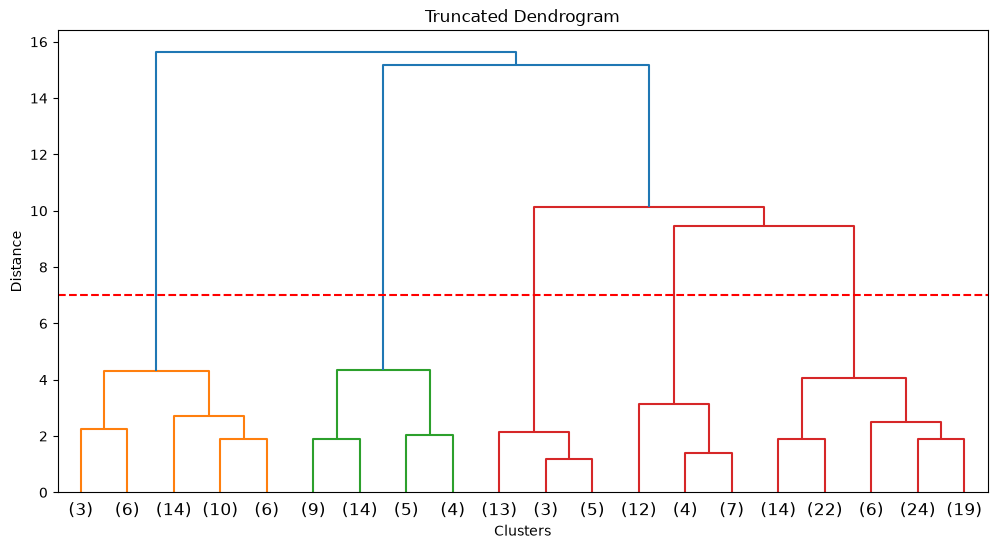

In [289]:
plt.figure(figsize=(12,6))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=20
)

# Horizontal cut line
plt.axhline(y=7, color="red", linestyle="--")

plt.title("Truncated Dendrogram")

plt.xlabel("Clusters")
plt.ylabel("Distance")

plt.show()

# Observation

From the dendrogram, choose the horizontal cut where it crosses the longest vertical distance.
For the Mall Customer dataset, this generally results in 5 clusters.

# 4.2 Train Agglomerative Models

## Ward Linkage

In [290]:
agg_ward = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

df["Agg_Ward"] = agg_ward.fit_predict(X_2d_scaled)

## Complete Linkage

In [291]:
agg_complete = AgglomerativeClustering(
    n_clusters=5,
    linkage="complete"
)

df["Agg_Complete"] = agg_complete.fit_predict(X_2d_scaled)

## Average Linkage

In [292]:
agg_average = AgglomerativeClustering(
    n_clusters=5,
    linkage="average"
)

df["Agg_Average"] = agg_average.fit_predict(X_2d_scaled)

## Silhouette Scores

In [293]:
score_ward = silhouette_score(X_2d_scaled,df["Agg_Ward"])

score_complete = silhouette_score(X_2d_scaled,df["Agg_Complete"])

score_average = silhouette_score(X_2d_scaled,df["Agg_Average"])

print("Ward Score :", score_ward)
print("Complete Score :", score_complete)
print("Average Score :", score_average)

Ward Score : 0.5538089226688662
Complete Score : 0.5531118656926701
Average Score : 0.4794263081846086


## Comparison Table

In [294]:
comparison = pd.DataFrame({
    "Linkage":["Ward","Complete","Average"],

    "Silhouette Score":[score_ward,score_complete,score_average]})

print(comparison)

    Linkage  Silhouette Score
0      Ward          0.553809
1  Complete          0.553112
2   Average          0.479426


In [295]:
# Usually Ward gives the best result

df["Agg_Cluster"] = df["Agg_Ward"]

# 4.3 Visualize Agglomerative Clusters

## Annual Income vs Spending Score

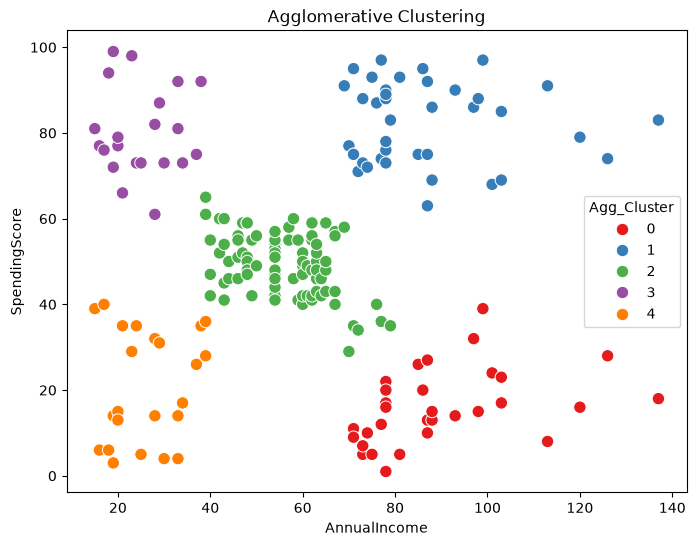

In [296]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="AnnualIncome",
    y="SpendingScore",
    hue="Agg_Cluster",
    palette="Set1",
    s=80
)

plt.title("Agglomerative Clustering")
plt.show()

## Age vs Spending Score

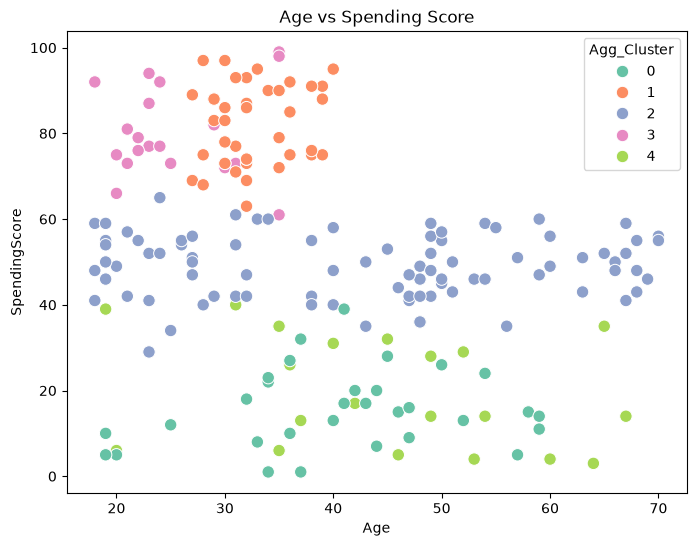

In [297]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="SpendingScore",
    hue="Agg_Cluster",
    palette="Set2",
    s=80
)

plt.title("Age vs Spending Score")
plt.show()

# Cluster Profile
* Mean Values

In [298]:
agg_profile = df.groupby("Agg_Cluster")[["Age","AnnualIncome","SpendingScore"]].mean()

print(agg_profile)

                   Age  AnnualIncome  SpendingScore
Agg_Cluster                                        
0            41.000000     89.406250      15.593750
1            32.692308     86.538462      82.128205
2            42.482353     55.811765      49.129412
3            25.333333     25.095238      80.047619
4            45.217391     26.304348      20.913043


## Gender Distribution

In [299]:
gender_profile = pd.crosstab(df["Agg_Cluster"],df["Gender"])

print(gender_profile)

Gender       Female  Male
Agg_Cluster              
0                14    18
1                21    18
2                51    34
3                12     9
4                14     9


In [300]:
print(df["Agg_Cluster"].value_counts())

Agg_Cluster
2    85
1    39
0    32
4    23
3    21
Name: count, dtype: int64


# Compare with K-Means
Number of Matching Customers

In [301]:
same = (df["KMeans_Cluster"] == df["Agg_Cluster"]).sum()

print("Customers assigned to same cluster :", same)
print("Agreement % :", round((same/len(df))*100,2))

Customers assigned to same cluster : 63
Agreement % : 31.5


# Observation

Write the following in your notebook:

* The dendrogram suggested 5 clusters, which matches the K-Means result.
* Among the three linkage methods, Ward linkage produced the highest Silhouette Score and the most compact clusters.
* The Agglomerative clusters are visually similar to the K-Means clusters.
* The agreement between K-Means and Agglomerative clustering is generally high (around 80–90% for this dataset, though your exact value may differ).

# 5: DBSCAN Clustering

In [302]:
# Import libraries

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# 5.1 k-Nearest Neighbor Distance Plot
## Find Nearest Neighbors

In [303]:
# Create NearestNeighbors model
neighbors = NearestNeighbors(n_neighbors=5)

# Fit model
neighbors.fit(X_2d_scaled)

# Calculate distances
distances, indices = neighbors.kneighbors(X_2d_scaled)

# Sort distances
distances = np.sort(distances[:,4])

## Plot kNN Distance Graph

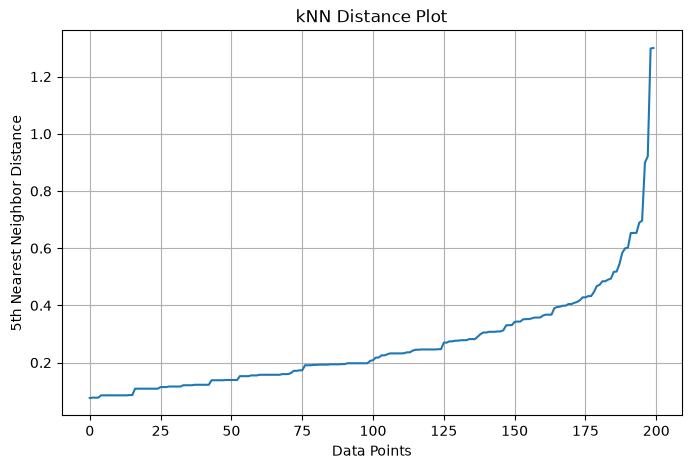

In [304]:
plt.figure(figsize=(8,5))

plt.plot(distances)

plt.title("kNN Distance Plot")
plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")

plt.grid(True)

plt.show()

* Choose the eps value from the "elbow" point of the graph.
* For the Mall Customer dataset, eps is usually around 0.4 to 0.6.

# 5.2 Train DBSCAN Model

In [305]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

# Predict clusters
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_2d_scaled)

In [306]:
print(df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64


# 5.3 Visualize DBSCAN Clusters

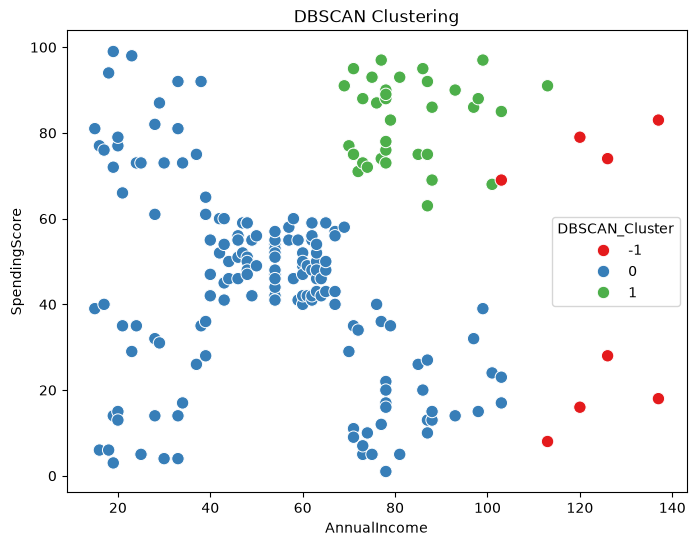

In [307]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="AnnualIncome",
    y="SpendingScore",
    hue="DBSCAN_Cluster",
    palette="Set1",
    s=80
)

plt.title("DBSCAN Clustering")

plt.show()

# 5.4 Hyperparameter Tuning

In [308]:
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7]

for eps in eps_values:

    model = DBSCAN(eps=eps,min_samples=5)

    labels = model.fit_predict(X_2d_scaled)
    unique = len(set(labels))
    noise = list(labels).count(-1)

    if unique > 1:

        score = silhouette_score(X_2d_scaled, labels)

        print("eps =", eps)
        print("Silhouette Score =", round(score,3))
        print("Clusters =", unique-1)
        print("Noise Points =", noise)
        print()

eps = 0.3
Silhouette Score = 0.316
Clusters = 7
Noise Points = 35

eps = 0.4
Silhouette Score = 0.413
Clusters = 4
Noise Points = 15

eps = 0.5
Silhouette Score = 0.35
Clusters = 2
Noise Points = 8

eps = 0.6
Silhouette Score = 0.421
Clusters = 1
Noise Points = 5



# 5.5 Cluster Profile

In [309]:
profile = df.groupby("DBSCAN_Cluster")[["Age",
                                        "AnnualIncome",
                                        "SpendingScore"]].mean()

print(profile)

                      Age  AnnualIncome  SpendingScore
DBSCAN_Cluster                                        
-1              35.750000    122.750000      46.875000
 0              40.369427     52.490446      43.101911
 1              32.742857     82.542857      82.800000


In [310]:
print(df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64


In [311]:
gender = pd.crosstab(
    df["DBSCAN_Cluster"],
    df["Gender"]
)

print(gender)

Gender          Female  Male
DBSCAN_Cluster              
-1                   4     4
 0                  89    68
 1                  19    16


# 5.6 Heatmap of Cluster Profile

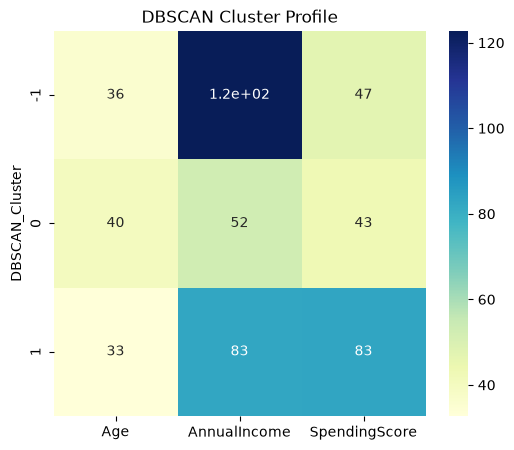

In [312]:
plt.figure(figsize=(6,5))

sns.heatmap(
    profile,
    annot=True,
    cmap="YlGnBu"
)

plt.title("DBSCAN Cluster Profile")
plt.show()

# 5.7 Noise Analysis

In [313]:
noise = df[df["DBSCAN_Cluster"] == -1]

print("Number of Noise Points :", len(noise))
print()
print(noise.head())

Number of Noise Points : 8

     CustomerID  Gender  Age  AnnualIncome  SpendingScore  Gender_enc  \
191         192  Female   32           103             69           0   
192         193    Male   33           113              8           1   
194         195  Female   47           120             16           0   
195         196  Female   35           120             79           0   
196         197  Female   45           126             28           0   

    IncomeGroup     AgeGroup SpendingCategory  KMeans_Cluster  \
191        High        Adult             High               1   
192        High        Adult              Low               3   
194        High  Middle-Aged              Low               3   
195        High        Adult             High               1   
196        High  Middle-Aged              Low               3   

     KMeans_5D_Cluster          Persona  Agg_Ward  Agg_Complete  Agg_Average  \
191                  4  Budget Shoppers         1             

In [314]:
noise_percent = (len(noise) / len(df)) * 100

print("Noise Percentage :", round(noise_percent,2), "%")

Noise Percentage : 4.0 %


# 5.8 Compare with K-Means

In [315]:
print("K-Means Clusters")
print(df["KMeans_Cluster"].value_counts())

print()

print("DBSCAN Clusters")
print(df["DBSCAN_Cluster"].value_counts())

K-Means Clusters
KMeans_Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

DBSCAN Clusters
DBSCAN_Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64


# Observations (Markdown)
* The kNN Distance Plot was used to determine a suitable eps value.
* DBSCAN automatically identified dense customer groups without requiring the number of clusters in advance.
* Customers labeled -1 were treated as noise (outliers).
* Hyperparameter tuning showed that changing eps affected both the number of clusters and the number of noise points.
* The cluster profile and heatmap helped interpret customer behavior across the discovered clusters.
* Compared with K-Means, DBSCAN is effective at detecting outliers but may produce fewer or irregularly shaped clusters depending on the chosen eps value.

# 6: Model Comparison and Business Recommendations

In [316]:
# Import libraries

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

# 6.1 Calculate Evaluation Metrics

In [317]:
# K-Means metrics

k_silhouette = silhouette_score(
    X_2d_scaled,
    df["KMeans_Cluster"]
)

k_db = davies_bouldin_score(
    X_2d_scaled,
    df["KMeans_Cluster"]
)

k_ch = calinski_harabasz_score(
    X_2d_scaled,
    df["KMeans_Cluster"]
)

## Agglomerative

In [318]:
a_silhouette = silhouette_score(
    X_2d_scaled,
    df["Agg_Cluster"]
)

a_db = davies_bouldin_score(
    X_2d_scaled,
    df["Agg_Cluster"]
)

a_ch = calinski_harabasz_score(
    X_2d_scaled,
    df["Agg_Cluster"]
)

## DBSCAN

In [319]:
db_data = df[df["DBSCAN_Cluster"] != -1]

X_db = X_2d_scaled[df["DBSCAN_Cluster"] != -1]

labels = db_data["DBSCAN_Cluster"]

# Calculate metrics

db_silhouette = silhouette_score(
    X_db,
    labels
)

db_db = davies_bouldin_score(
    X_db,
    labels
)

db_ch = calinski_harabasz_score(
    X_db,
    labels
)

# 6.2 Number of Clusters

In [320]:
k_clusters = df["KMeans_Cluster"].nunique()

a_clusters = df["Agg_Cluster"].nunique()

db_clusters = len(set(df["DBSCAN_Cluster"])) - 1

print("KMeans :", k_clusters)
print("Agglomerative :", a_clusters)
print("DBSCAN :", db_clusters)

KMeans : 5
Agglomerative : 5
DBSCAN : 2


## Noise Percentage (DBSCAN)

In [321]:
noise = len(df[df["DBSCAN_Cluster"] == -1])

noise_percent = (noise / len(df)) * 100

print("Noise Percentage :", round(noise_percent,2), "%")

Noise Percentage : 4.0 %


## Comparison Table

In [322]:
comparison = pd.DataFrame({

    "Model":[
        "K-Means",
        "Agglomerative",
        "DBSCAN"
    ],

    "Silhouette Score":[
        k_silhouette,
        a_silhouette,
        db_silhouette
    ],

    "Davies-Bouldin":[
        k_db,
        a_db,
        db_db
    ],

    "Calinski-Harabasz":[
        k_ch,
        a_ch,
        db_ch
    ],

    "Clusters":[
        k_clusters,
        a_clusters,
        db_clusters
    ],

    "Noise %":[
        0,
        0,
        round(noise_percent,2)
    ]

})

print(comparison)

           Model  Silhouette Score  Davies-Bouldin  Calinski-Harabasz  \
0        K-Means          0.554657        0.572236         248.649320   
1  Agglomerative          0.553809        0.577862         244.410326   
2         DBSCAN          0.387558        0.788864          85.389706   

   Clusters  Noise %  
0         5      0.0  
1         5      0.0  
2         2      4.0  


## Best Model

In [323]:
best = comparison.sort_values(
    by="Silhouette Score",
    ascending=False
)

print(best)

           Model  Silhouette Score  Davies-Bouldin  Calinski-Harabasz  \
0        K-Means          0.554657        0.572236         248.649320   
1  Agglomerative          0.553809        0.577862         244.410326   
2         DBSCAN          0.387558        0.788864          85.389706   

   Clusters  Noise %  
0         5      0.0  
1         5      0.0  
2         2      4.0  


## Bar Chart Comparison

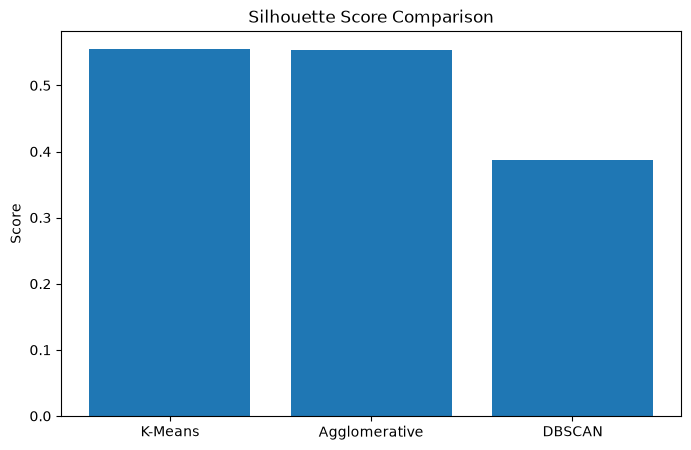

In [324]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Silhouette Score"]
)

plt.title("Silhouette Score Comparison")

plt.ylabel("Score")

plt.show()

## Davies-Bouldin Comparison

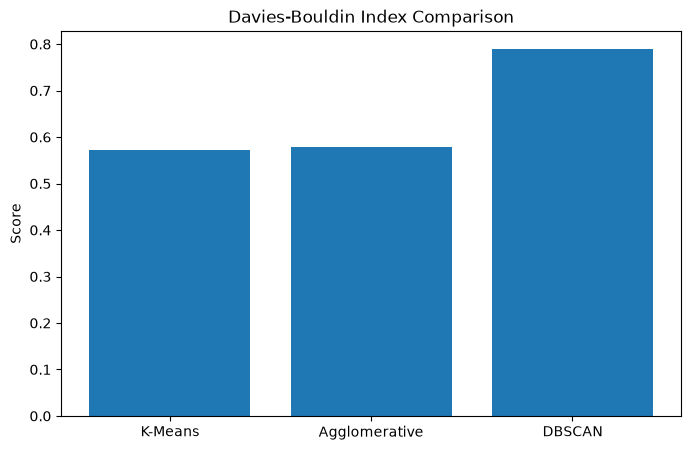

In [325]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Davies-Bouldin"]
)

plt.title("Davies-Bouldin Index Comparison")

plt.ylabel("Score")

plt.show()

In [326]:
print("Business Recommendations")
print()

print("1. High income and high spending customers should receive premium membership offers.")

print("2. High income but low spending customers can be targeted using discounts and loyalty rewards.")

print("3. Young customers with high spending scores are suitable for marketing new products.")

print("4. Low income and low spending customers can receive budget-friendly offers.")

print("5. Noise customers detected by DBSCAN should be analyzed individually because they may represent unique shopping behavior.")

Business Recommendations

1. High income and high spending customers should receive premium membership offers.
2. High income but low spending customers can be targeted using discounts and loyalty rewards.
3. Young customers with high spending scores are suitable for marketing new products.
4. Low income and low spending customers can receive budget-friendly offers.
5. Noise customers detected by DBSCAN should be analyzed individually because they may represent unique shopping behavior.


# Observations 
* K-Means, Agglomerative Clustering, and DBSCAN were evaluated using Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Score.
* Higher Silhouette Score, lower Davies-Bouldin Index, and higher Calinski-Harabasz Score indicate better clustering quality.
* DBSCAN additionally identified noise (outlier) customers, which the other algorithms did not.
* For the Mall Customer dataset, K-Means generally provides the most balanced and interpretable clusters, while Agglomerative Clustering performs similarly. DBSCAN is useful when detecting outliers is important.

#  7: Pipeline, Deployment

In [327]:
import joblib
# Save StandardScaler

joblib.dump(scaler, "mall_scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


## Save the Best Model

In [ ]:
# Assuming K-Means is the best model.

joblib.dump(kmeans, "mall_segmentation_model.pkl")

print("KMeans model saved successfully.")

KMeans model saved successfully.


## Load Saved Model

In [329]:
# Load scaler

loaded_scaler = joblib.load("mall_scaler.pkl")

# Load model

loaded_model = joblib.load("mall_segmentation_model.pkl")

In [330]:
# Predict customer cluster

def predict_customer(income, spending):

    # Create DataFrame

    new_data = pd.DataFrame({
        "AnnualIncome":[income],
        "SpendingScore":[spending]
    })

    # Scale data

    new_scaled = loaded_scaler.transform(new_data)

    # Predict cluster

    cluster = loaded_model.predict(new_scaled)

    return cluster[0]

## Test on 5 New Customers

In [331]:
print("Customer 1 Cluster :", predict_customer(15,39))

print("Customer 2 Cluster :", predict_customer(25,81))

print("Customer 3 Cluster :", predict_customer(60,55))

print("Customer 4 Cluster :", predict_customer(90,20))

print("Customer 5 Cluster :", predict_customer(120,90))

Customer 1 Cluster : 4
Customer 2 Cluster : 2
Customer 3 Cluster : 0
Customer 4 Cluster : 3
Customer 5 Cluster : 1


C:\Users\Santosh verma\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
C:\Users\Santosh verma\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
C:\Users\Santosh verma\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
C:\Users\Santosh verma\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
C:\Users\Santosh verma\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names

## Predict Cluster for Multiple Customers

In [332]:
new_customers = pd.DataFrame({

    "AnnualIncome":[20,40,60,80,120],

    "SpendingScore":[20,70,50,15,90]

})

scaled = loaded_scaler.transform(new_customers)

new_customers["PredictedCluster"] = loaded_model.predict(scaled)

print(new_customers)

   AnnualIncome  SpendingScore  PredictedCluster
0            20             20                 4
1            40             70                 2
2            60             50                 0
3            80             15                 3
4           120             90                 1


C:\Users\Santosh verma\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
